In [1]:
import yaml
import subprocess
import numpy as np
import pandas as pd
from formulaic import model_matrix
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercep="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

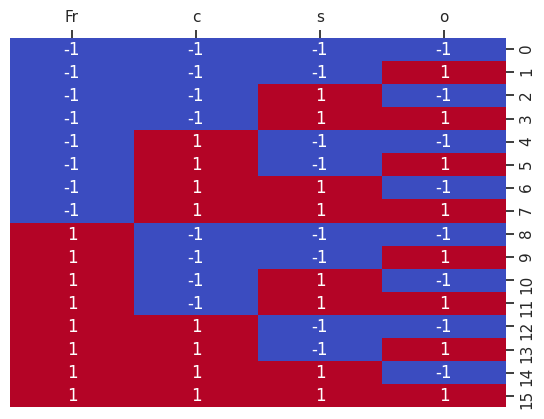

In [2]:
def factorial_2(N: int, S: int=2):
    rows = np.arange(S**N)
    periods = S**np.arange(0, N)[::-1]
    E = 2*(rows[:, None] % periods == 0) - 1
    return np.cumprod(-E, axis=0)

columns = "Fr c s o".split()
E = factorial_2(len(columns))
E = pd.DataFrame(E, columns=columns)

show_matrix(E)
plt.show()

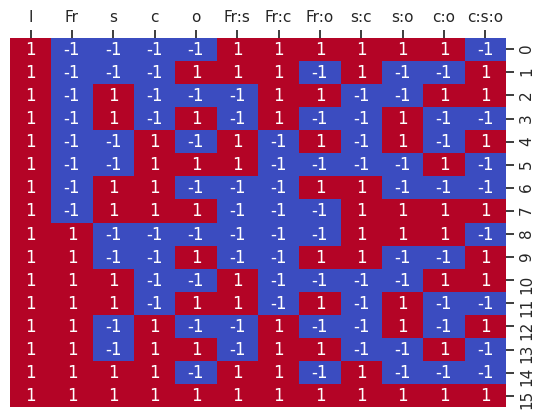

In [3]:
M = model_matrix("Fr+s+c+o + Fr:s + Fr:c + Fr:o + s:c + s:o + c:o + c:s:o", E).rename(columns=dict(Intercept="I"))
show_matrix(M)
M.to_csv("matrix_model.csv", index=False)

In [12]:
# Pour les simulations
min_max_values = pd.DataFrame(dict(
    Fr=[5, 15],
    s=(0.5, 1.5),
    c=(-0.0005, 0.0005),
    o=(0, 1)
))
min_values = min_max_values.iloc[0]
max_values = min_max_values.iloc[1]

values = (max_values-min_values) * (1+E)/2 + min_values
values.to_csv("matrix_experiment.csv", index=False)
display(values)

,Fr,c,o,s
0,5.0,-0.0005,0.0,0.5
1,5.0,-0.0005,1.0,0.5
2,5.0,-0.0005,0.0,1.5
3,5.0,-0.0005,1.0,1.5
4,5.0,0.0005,0.0,0.5
5,5.0,0.0005,1.0,0.5
6,5.0,0.0005,0.0,1.5
7,5.0,0.0005,1.0,1.5
8,15.0,-0.0005,0.0,0.5
9,15.0,-0.0005,1.0,0.5


In [16]:
config = dict(
    xmin=-50,
    xmax=+2e3,
    ymin=-1000,
    ymax=1000,
    avalanche_depth=2,  # m
    avalanche_volume=2000,  # m³
    avalanche_width=100,  # m
    avalanche_speed=None,
    slope=None,
    curvature=None,
    openness=None,
)

outdir = "/media/giboul/Data/Giboulot/DoE/_output{i:0>4}"

for experiment in range(E.shape[0]):
    
    config.update(
        avalanche_speed=float(values["Fr"].iloc[experiment]*np.sqrt(9.81*config["avalanche_depth"])),
        slope=float(values["s"].iloc[experiment]),
        curvature=float(values["c"].iloc[experiment]),
        openness=float(values["o"].iloc[experiment]),
    )
    with open("config.yaml", "w") as file:
        yaml.safe_dump(config, file)
    path = outdir.format(i=experiment)
    print(f"{path}: ", end="", flush=True)
    output = subprocess.run(
        f"make simulation OUTDIR={path} OMP_NUM_PROCS=10".split(),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )
    print(output.returncode, flush=True)

/media/giboul/Data/Giboulot/DoE/_output0000: 0
/media/giboul/Data/Giboulot/DoE/_output0001: 0
/media/giboul/Data/Giboulot/DoE/_output0002: 0
/media/giboul/Data/Giboulot/DoE/_output0003: 0
/media/giboul/Data/Giboulot/DoE/_output0004: 0
/media/giboul/Data/Giboulot/DoE/_output0005: 0
/media/giboul/Data/Giboulot/DoE/_output0006: 0
/media/giboul/Data/Giboulot/DoE/_output0007: 0
/media/giboul/Data/Giboulot/DoE/_output0008: 0
/media/giboul/Data/Giboulot/DoE/_output0009: 0
/media/giboul/Data/Giboulot/DoE/_output0010: 0
/media/giboul/Data/Giboulot/DoE/_output0011: 0
/media/giboul/Data/Giboulot/DoE/_output0012: 0
/media/giboul/Data/Giboulot/DoE/_output0013: 0
/media/giboul/Data/Giboulot/DoE/_output0014: 0
/media/giboul/Data/Giboulot/DoE/_output0015: 0


In [ ]:
from pathlib import Path
from clawpack.geoclaw import fgmax_tools

files = Path("/media/giboul/Data/Giboulot/DoE/").glob("_output*")
hmax = np.zeros(E.shape[0], dtype=np.float64)
for i, outdir in enumerate(sorted(files)):
    fg = fgmax_tools.FGmaxGrid()
    print(outdir / "fgmax_grids.data")
    fg.read_fgmax_grids_data(2, outdir / "fgmax_grids.data")
    fg.read_output(outdir=outdir)
    hmax[i] = fg.h.max()
print(hmax)
np.savetxt("hmax.txt", hmax[:, None])

/media/giboul/Data/Giboulot/DoE/_output0000/fgmax_grids.data
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0000/fgmax0002.txt ...
/media/giboul/Data/Giboulot/DoE/_output0001/fgmax_grids.data
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0001/fgmax0002.txt ...
/media/giboul/Data/Giboulot/DoE/_output0002/fgmax_grids.data
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0002/fgmax0002.txt ...
/media/giboul/Data/Giboulot/DoE/_output0003/fgmax_grids.data
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0003/fgmax0002.txt ...
/media/giboul/Data/Giboulot/DoE/_output0004/fgmax_grids.data
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0004/fgmax0002.txt ...
/media/giboul/Data/Giboulot/DoE/_output0005/fgmax_grids.data
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data